In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

from lg_analogues import (
    load_header_constants,
    select_central_plus_largest_satellite_by_stellar_mass,
    find_pairs_periodic,
    isolation_filter_no_third_factor_x_in_same_group,
)

basePath = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
snap = 99

# Load header constants (h and box size)
const = load_header_constants(basePath, snap)
h = const["h"]
box = const["box_ckpch"]

print("h:", h)
print("BoxSize [ckpc/h]:", box)


h: 0.6774
BoxSize [ckpc/h]: 205000.0


In [8]:
# Load subhalo fields needed for selection and pair finding
subhalo_fields = [ 
    "SubhaloPos",       # Spatial position within the periodic box (of the particle with the minium gravitational potential energy). Comoving coordinate. Units: ckpc/h 
    "SubhaloVel",       # Peculiar velocity of the group, computed as the sum of the mass weighted velocities of all particles/cells in this group, of all types. No unit conversion is needed. Units: km/s
    "SubhaloMass",      # Total mass of all member particle/cells which are bound to this Subhalo, of all types. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloMassType",  # Total mass of all member particle/cells which are bound to this Subhalo, separated by type. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloSFR",       # Sum of the individual star formation rates of all gas cells in this subhalo. Units Msun/yr
    "SubhaloSFRinRad",  # Sum of the individual star formation rates of all gas cells in this subhalo, but restricted to cells within the radius of 𝑉𝑚𝑎𝑥. Units Msun/yr
    "SubhaloFlag",      # Flag field indicating suitability of this subhalo for certain types of analysis. If zero, this subhalo should generally be excluded, and is not thought to be of cosmological origin.
    "SubhaloGrNr"       # Index into the Group table of the FOF host/parent of this Subhalo. 
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
print("All subhalos:", sub["count"])


All subhalos: 14485709


## Stellar mass

Next we to compute stellar mass per central subhalo and keep only objects in a reasonable stellar-mass range. This matters because pair-finding on ~11.5 million centrals will still be heavy, while pair-finding on (say) a few hundred thousand “MW-ish” centrals is manageable.

### What “stellar mass” is in this table

SubhaloMassType is mass by particle type, in units of 1e10 Msun/h. The type mapping is the standard TNG particle-type convention: PartType4 = stars & wind particles, PartType1 = dark matter.

Mstar = SubhaloMassType[:, 4] * 1e10 / h (Msun)

Mdm = SubhaloMassType[:, 1] * 1e10 / h (Msun)

TNG300-1 lists "h" as 0.6774.

In [9]:
# Selection: centrals with stellar mass in window, plus largest satellite in window (per FoF group)
mstar_min = 2e10
mstar_max = 5e11

sample = select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=mstar_min,
    mstar_max=mstar_max,
)

print("Sample size:", sample.pos.shape[0])
print("Stellar mass range [Msun]:", float(sample.mstar.min()), float(sample.mstar.max()))
print("Groups represented:", np.unique(sample.grnr).size)


Sample size: 45392
Stellar mass range [Msun]: 20000320076.4145 499936405944.3737
Groups represented: 38778


### Sanity plot (stellar mass vs DM mass) for filtered groups

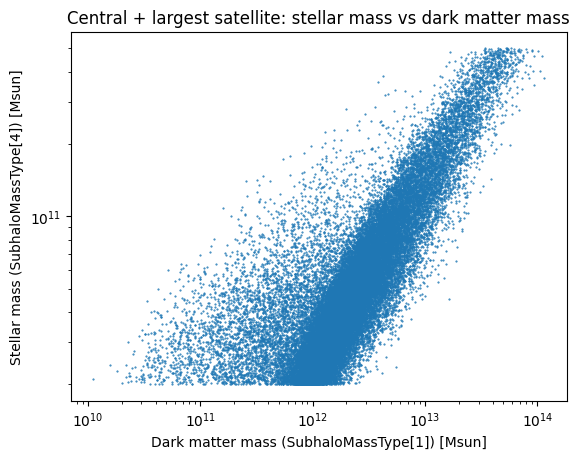

In [10]:
# SubhaloMassType units are 1e10 Msun/h
mstar = sample.mtype[:, 4].astype(np.float64) * 1e10 / h
mdm = sample.mtype[:, 1].astype(np.float64) * 1e10 / h

plt.figure()
plt.plot(mdm, mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Dark matter mass (SubhaloMassType[1]) [Msun]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: stellar mass vs dark matter mass")
plt.show()

### Prepare for pair-finding (define the distance window)

Key detail: SubhaloPos is in ckpc/h (comoving kpc divided by h).
At snapshot 99, z=0, so comoving = physical length, and the conversion to kpc is:

kpc = (ckpc/h) / h

equivalently, ckpc/h = kpc * h

In [11]:
# Pair finding (periodic), 500–1000 kpc
pairs = find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box,
    r_min_kpc=500.0,
    r_max_kpc=1000.0,
)

print("Pairs:", pairs.i.size)
print("Same-host pairs:", int(pairs.same_host.sum()))
print("Different-host pairs:", int((~pairs.same_host).sum()))


Pairs: 2655
Same-host pairs: 2084
Different-host pairs: 571


In [14]:
# Isolation filter: no third subhalo in same FoF group(s) >= x times more massive than the larger pair member
x = 2.0

keep_iso = isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pair_i=pairs.i,
    pair_j=pairs.j,
    sample_grnr=sample.grnr,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    x=x,
)

print("Pairs after isolation:", int(keep_iso.sum()))

Pairs after isolation: 2620


### Categorization of galaxies by their type (elliptical vs spiral) based on sSFR (Star Formation Rate (SFR) / Stellar mass (M*) ratio)

In [18]:
# Pair indices after isolation
ii = pairs.i[keep_iso]
jj = pairs.j[keep_iso]

# Stellar masses for sample objects (Msun)
mstar_s = sample.mstar

sfr_s = sub["SubhaloSFRinRad"][sample.keep_idx].astype(np.float64)

In [19]:
# Pair member masses and SFRs
Mi_star = mstar_s[ii]
Mj_star = mstar_s[jj]
Si = sfr_s[ii]
Sj = sfr_s[jj]

# Valid masks (avoid divide-by-zero)
valid_i = Mi_star > 0
valid_j = Mj_star > 0
valid_pair = valid_i & valid_j

# sSFR (1/yr); keep arrays same length, set invalid entries to nan
sSFR_i = np.full(ii.shape[0], np.nan, dtype=np.float64)
sSFR_j = np.full(ii.shape[0], np.nan, dtype=np.float64)
sSFR_i[valid_i] = Si[valid_i] / Mi_star[valid_i]
sSFR_j[valid_j] = Sj[valid_j] / Mj_star[valid_j]

# Prints
print("Selected counts (after isolation):")
print("All sample objects:", len(mstar_s))
print("Pairs after isolation:", len(ii))

print("Pairs where i mass == 0:", int((Mi_star == 0).sum()))
print("Pairs where j mass == 0:", int((Mj_star == 0).sum()))
print("Pairs where both mass == 0:", int(((Mi_star == 0) & (Mj_star == 0)).sum()))
print("Pairs where either mass == 0:", int(((Mi_star == 0) | (Mj_star == 0)).sum()))

print("Pairs with both masses > 0:", int(valid_pair.sum()))
print("Fraction with both masses > 0:", float(valid_pair.mean()))

print("Finite sSFR_i:", int(np.isfinite(sSFR_i).sum()))
print("Finite sSFR_j:", int(np.isfinite(sSFR_j).sum()))

Selected counts (after isolation):
All sample objects: 45392
Pairs after isolation: 2620
Pairs where i mass == 0: 0
Pairs where j mass == 0: 0
Pairs where both mass == 0: 0
Pairs where either mass == 0: 0
Pairs with both masses > 0: 2620
Fraction with both masses > 0: 1.0
Finite sSFR_i: 2620
Finite sSFR_j: 2620


##### Summary
- Due to the ratio, the stellar mass cannot be zero. With current pair finding algorithm, 89% of the pairs have at least one subhalo with stellar mass of zero, so most of the pairs have to be dropped out for this categorization. Expecting this phenomenon to change once we update the pair finding.
- So to be noted that currently, 197 out of 1751 pairs have both galaxies with stellar mass > 0 and are part of the below analysis.
- Out of these 197 pairs, the huge majority is galaxies with SFR=0, i.e. "dead" galaxies, which count towards elliptical galaxies...Wondering if that will change, too.
- Andromeda-Milkyway is spiral-spiral. There is currently one such pair...
- Additional notes below plots.

In [25]:
# Classification, use log for easy comparison.
log_sSFR_i = np.log10(sSFR_i + 1e-16) # Adding small number to avoid log(0) as many galaxies have SFR=0.
log_sSFR_j = np.log10(sSFR_j + 1e-16)

# Standard based on galaxy evolution studies (source: ChatGPT for now)
spiral_i = log_sSFR_i > -11 # Star forming > spiral
elliptical_i = log_sSFR_i <= -11 # quenched > elliptical

spiral_j = log_sSFR_j > -11 # Star forming > spiral
elliptical_j = log_sSFR_j <= -11 # quenched > elliptical

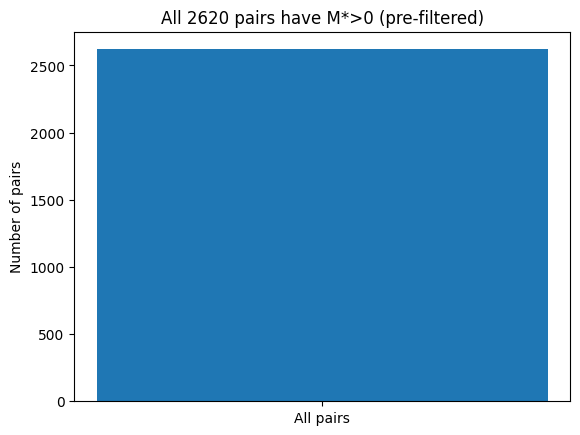

In [26]:
total_pairs = len(ii)

plt.bar(["All pairs"], [total_pairs])
plt.ylabel("Number of pairs")
plt.title(f"All {total_pairs} pairs have M*>0 (pre-filtered)")
plt.show()

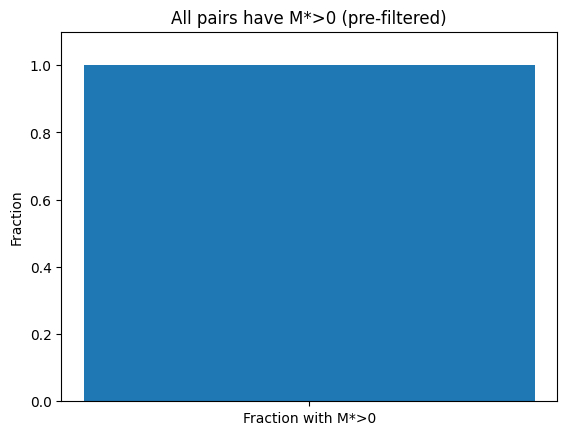

In [23]:
plt.bar(["Fraction with M*>0"], [1.0])
plt.ylabel("Fraction")
plt.ylim(0, 1.1)
plt.title("All pairs have M*>0 (pre-filtered)")
plt.show()

In [ ]:
plt.scatter(
    np.log10(mstar_s[i]),
    np.log10(mstar_s[j]),
    s=10
)
plt.xlabel("log10(M*_i)")
plt.ylabel("log10(M*_j)")
plt.title("Stellar masses of pairs (w/ M*>0)")
x = np.linspace(7,12,100)
plt.plot(x, x, linestyle="--")

NameError: name 'i' is not defined

The masses differ within pairs.

Text(0.5, 1.0, 'sSFR_i vs sSFR_j: spiral-spiral top right corner')

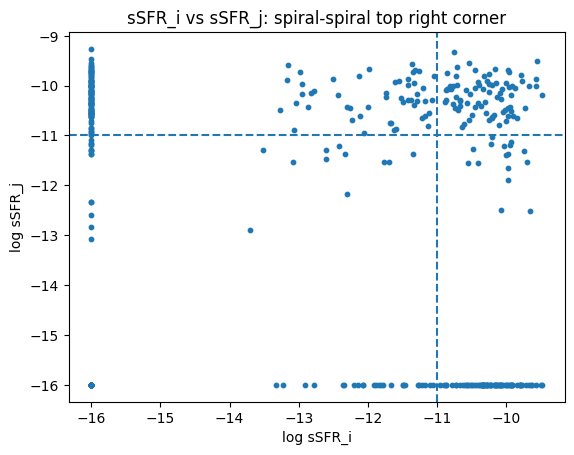

In [11]:
plt.scatter(log_sSFR_i, log_sSFR_j, s=10)
plt.axvline(-11, linestyle="--")
plt.axhline(-11, linestyle="--")
plt.xlabel("log sSFR_i")
plt.ylabel("log sSFR_j")
plt.title("sSFR_i vs sSFR_j: spiral-spiral top right corner")

# Double-checking the number of unique points as there are so many fewers points shown in graph than the sample size. >> The dots are on top of each.
#unique_points = len(np.unique(np.column_stack((log_sSFR_i, log_sSFR_j)), axis=0))
#print(unique_points)


- Many dots are on top of each other at -16/-16. These ones have SFR = 0 and are totally dead.
- sSFR > -11 spiral and sSFR <= -11 elliptical. So top-right corner = spiral-spiral, top-left and bottom-right = mixed, bottom-left = elliptical-elliptical

Text(0.5, 1.0, 'Density plot to show where most pairs lie')

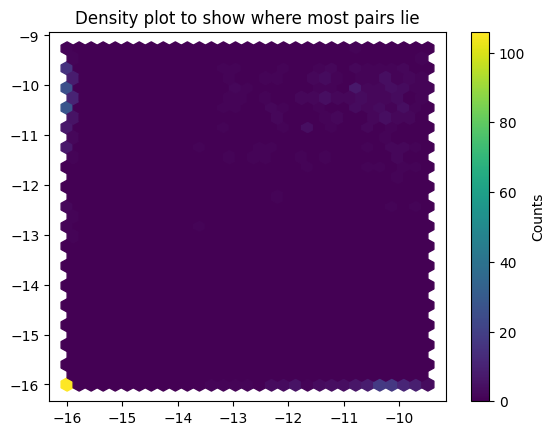

In [12]:
plt.hexbin(log_sSFR_i, log_sSFR_j, gridsize=30)
plt.colorbar(label="Counts")
plt.title("Density plot to show where most pairs lie")

Density plot on top describes the dominance of subhalo pairs with SFR = 0 or log(sSFR) = -16

Text(0.5, 1.0, 'Number of various types of pairs where both have M*>0')

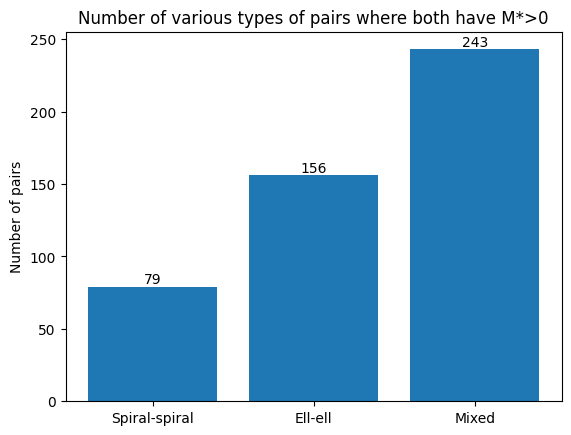

In [13]:
spiral_spiral = np.sum((log_sSFR_i > -11) & (log_sSFR_j > -11))
ell_ell = np.sum((log_sSFR_i <= -11) & (log_sSFR_j <= -11))
mixed = len(log_sSFR_i) - spiral_spiral - ell_ell

bars = plt.bar(
    ["Spiral-spiral", "Ell-ell", "Mixed"],
    [spiral_spiral, ell_ell, mixed]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.ylabel("Number of pairs")
plt.title("Number of various types of pairs where both have M*>0")

The above plot describes the above plots and pair types in bars.

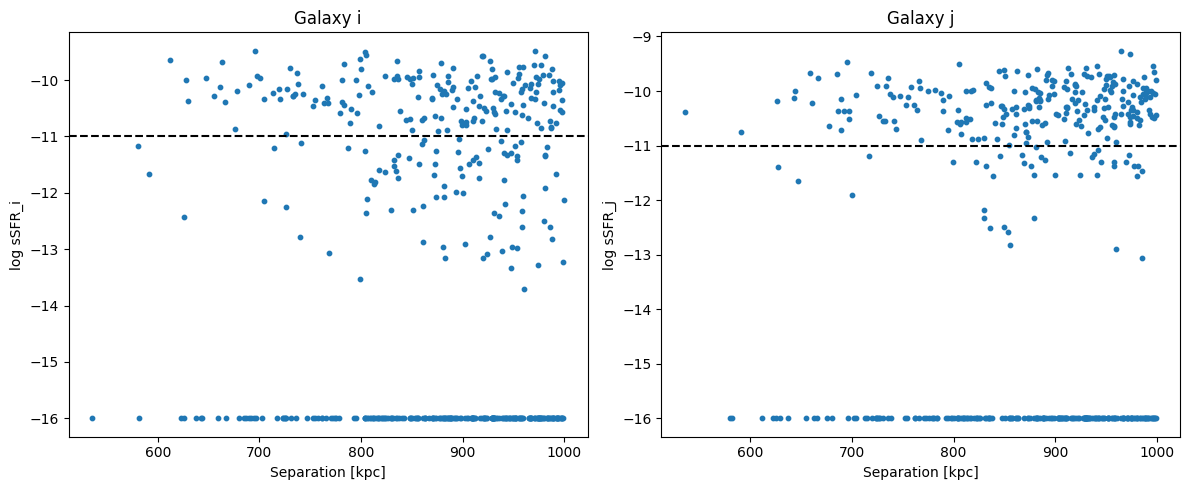

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: i
axes[0].scatter(dist_kpc, log_sSFR_i, s=10)
axes[0].set_xlabel("Separation [kpc]")
axes[0].set_ylabel("log sSFR_i")
axes[0].set_title("Galaxy i")
axes[0].axhline(-11, linestyle="--", color="k")

# Right: j
axes[1].scatter(dist_kpc, log_sSFR_j, s=10)
axes[1].set_xlabel("Separation [kpc]")
axes[1].set_ylabel("log sSFR_j")
axes[1].set_title("Galaxy j")
axes[1].axhline(-11, linestyle="--", color="k")

plt.tight_layout()

# plt.scatter(dist[mass_positive_pair], log_sSFR_i, s=10)
# plt.xlabel("Separation [ckpc/h]")
# plt.ylabel("log sSFR_i")

Above: Scatter plot of separation vs. sSFR i & j. Separation is spread out, so I cannot make any conclusions.

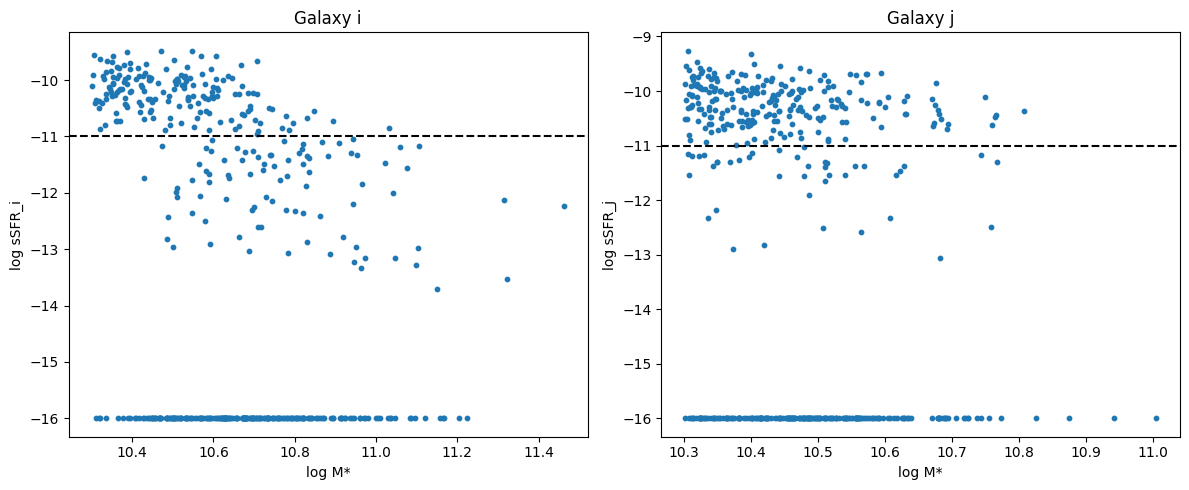

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: i
axes[0].scatter(np.log10(mstar_s[i]),
    log_sSFR_i, s=10)
axes[0].set_xlabel("log M*")
axes[0].set_ylabel("log sSFR_i")
axes[0].set_title("Galaxy i")
axes[0].axhline(-11, linestyle="--", color="k")

# Right: j
axes[1].scatter(np.log10(mstar_s[j]),
    log_sSFR_j, s=10)
axes[1].set_xlabel("log M*")
axes[1].set_ylabel("log sSFR_j")
axes[1].set_title("Galaxy j")
axes[1].axhline(-11, linestyle="--", color="k")

plt.tight_layout()

Above: Scatter plot of log(stellar mass) vs. sSFR i & j. Stellar masses are spread out.
Well, more elliptical galaxies in j, and those have rather bigger masses as expected.

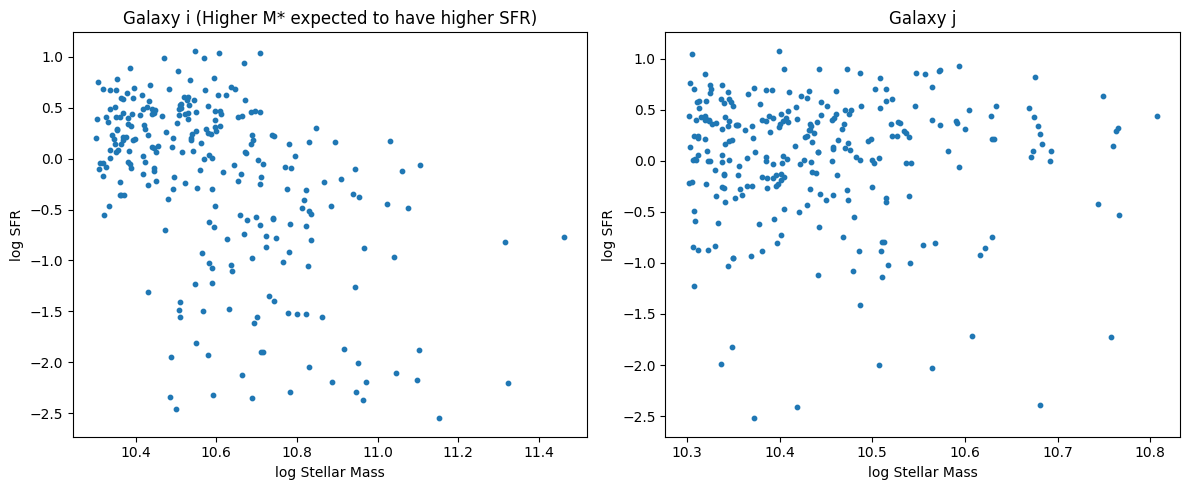

In [16]:
# Extract quantities for i and j
mass_i = mstar_s[i]
mass_j = mstar_s[j]
sfr_i = sfr_s[i]
sfr_j = sfr_s[j]

# Remove zero SFR values (cannot take log10 of zero)
valid_i = sfr_i > 0
valid_j = sfr_j > 0

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- Galaxy i ---
axes[0].scatter(
    np.log10(mass_i[valid_i]),
    np.log10(sfr_i[valid_i]),
    s=10
)
axes[0].set_xlabel("log Stellar Mass")
axes[0].set_ylabel("log SFR")
axes[0].set_title("Galaxy i (Higher M* expected to have higher SFR)")

# --- Galaxy j ---
axes[1].scatter(
    np.log10(mass_j[valid_j]),
    np.log10(sfr_j[valid_j]),
    s=10
)
axes[1].set_xlabel("log Stellar Mass")
axes[1].set_ylabel("log SFR")
axes[1].set_title("Galaxy j")

plt.tight_layout()
plt.show()


Above: Scatter plot of stellar mass vs SFR. Higher M* is expected to have higher SFR, so nothing surprising here.
Note, however, that higher M* is expected to have lower sSFR.

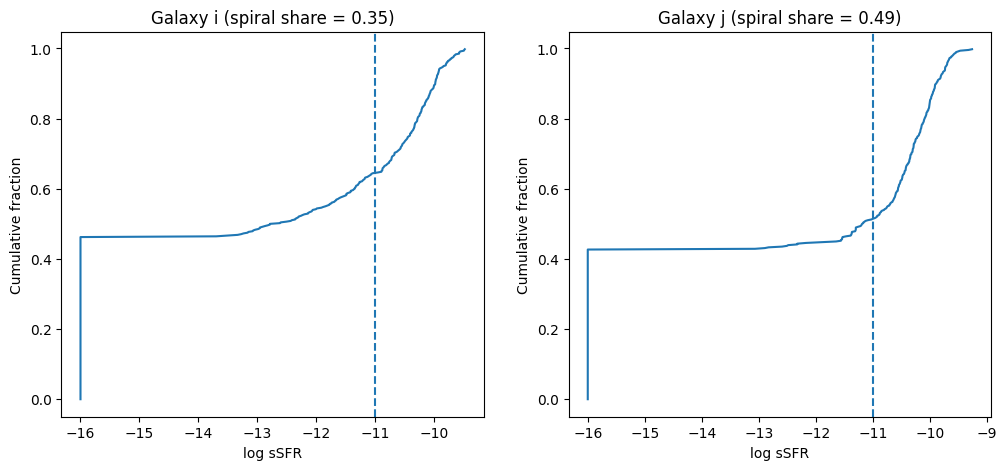

In [17]:
# Sort values for i
sorted_i = np.sort(log_sSFR_i)
cdf_i = np.arange(len(sorted_i)) / len(sorted_i)
spiral_frac_i = np.mean(log_sSFR_i > -11) # Calculate the share of spiral galaxies out of total

# Sort values for j
sorted_j = np.sort(log_sSFR_j)
cdf_j = np.arange(len(sorted_j)) / len(sorted_j)
spiral_frac_j = np.mean(log_sSFR_j > -11) # Calculate the share of sprial galaxies out of total

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left panel: galaxy i
axes[0].plot(sorted_i, cdf_i)
axes[0].axvline(-11, linestyle="--")
axes[0].set_xlabel("log sSFR")
axes[0].set_ylabel("Cumulative fraction")
axes[0].set_title(f"Galaxy i (spiral share = {spiral_frac_i:.2f})") #"Galaxy i: Cumulative fraction of galaxies based on their log(sSFR)")

# Right panel: galaxy j
axes[1].plot(sorted_j, cdf_j)
axes[1].axvline(-11, linestyle="--")
axes[1].set_xlabel("log sSFR")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title(f"Galaxy j (spiral share = {spiral_frac_j:.2f})")

plt.show()

Above: Cumulative pairs based on sSFR. Demonstrates the current emphasis on elliptical galaxies.

### Graphs

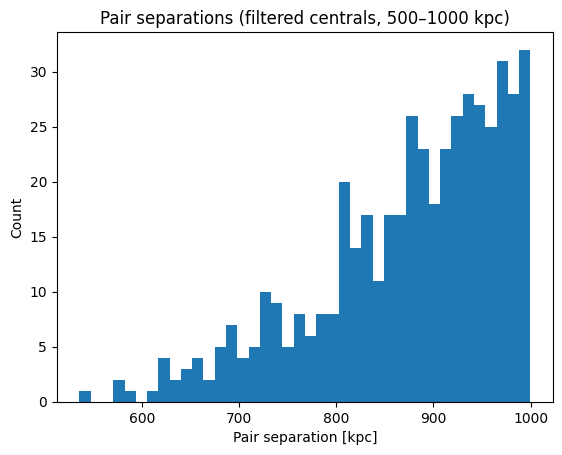

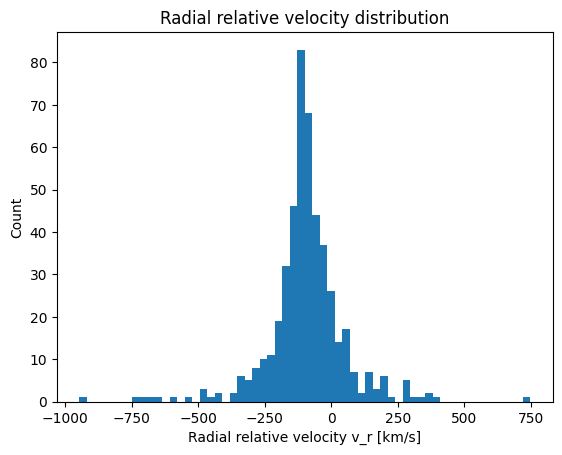

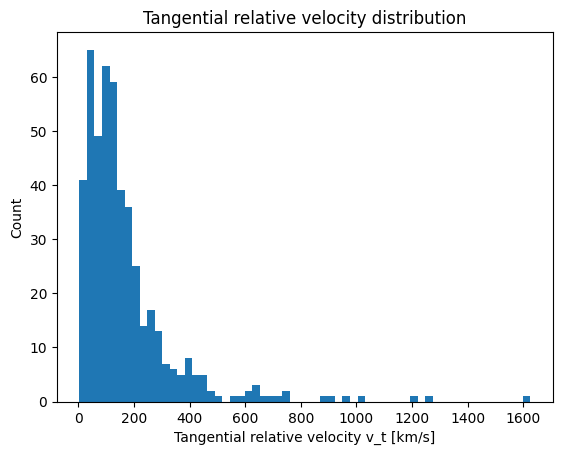

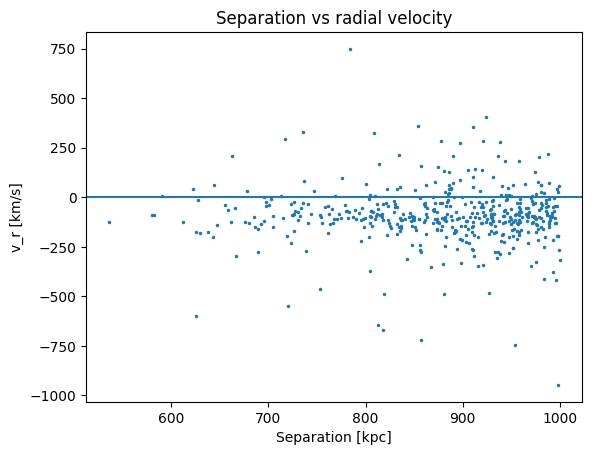

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Separation histogram (should be roughly uniform-ish inside the hard window)
plt.figure()
plt.hist(dist_kpc, bins=40)
plt.xlabel("Pair separation [kpc]")
plt.ylabel("Count")
plt.title("Pair separations (filtered centrals, 500–1000 kpc)")
plt.show()

# 2) Radial velocity histogram
plt.figure()
plt.hist(v_r, bins=60)
plt.xlabel("Radial relative velocity v_r [km/s]")
plt.ylabel("Count")
plt.title("Radial relative velocity distribution")
plt.show()

# 3) Tangential velocity histogram
plt.figure()
plt.hist(v_t, bins=60)
plt.xlabel("Tangential relative velocity v_t [km/s]")
plt.ylabel("Count")
plt.title("Tangential relative velocity distribution")
plt.show()

# 4) Separation vs v_r scatter
plt.figure()
plt.plot(dist_kpc, v_r, ".", markersize=3)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Separation vs radial velocity")
plt.axhline(0.0)  # r


Fast pairs: 21 out of 478


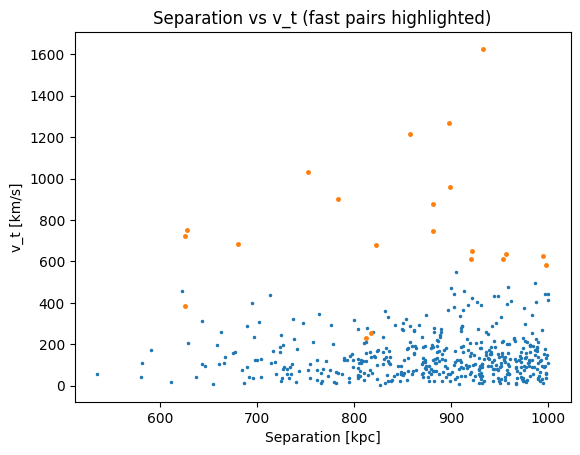

In [19]:
# Mark extreme outliers
# Identify very high-speed pairs for inspection (threshold is arbitrary, used only for debugging)
mask_fast = (np.abs(v_r) > 600) | (v_t > 600)

print("Fast pairs:", mask_fast.sum(), "out of", len(v_r))

plt.figure()
plt.plot(dist_kpc[~mask_fast], v_t[~mask_fast], ".", markersize=3)
plt.plot(dist_kpc[mask_fast],  v_t[mask_fast],  ".", markersize=5)
plt.xlabel("Separation [kpc]")
plt.ylabel("v_t [km/s]")
plt.title("Separation vs v_t (fast pairs highlighted)")
plt.show()


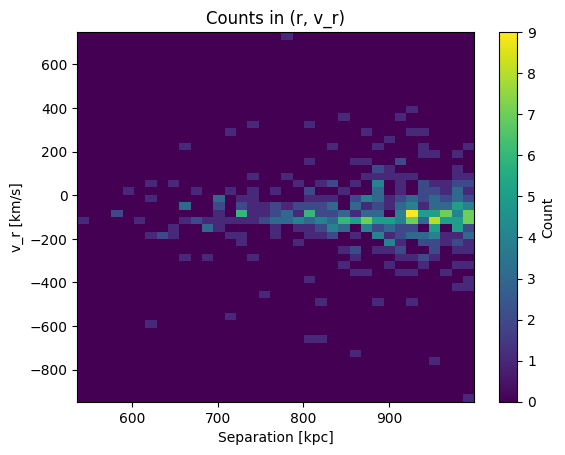

In [20]:
# Plot the joint distribution like the paper style (heatmap of counts in the (r, v_r) plane).
plt.figure()
plt.hist2d(dist_kpc, v_r, bins=[35, 50])
plt.xlabel("Separation [kpc]")
plt.ylabel("v_r [km/s]")
plt.title("Counts in (r, v_r)")
plt.colorbar(label="Count")
plt.show()
